In [1]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [2]:
# =========================================================
# 1. Load data
# =========================================================
df = pd.read_csv("preprocess/features_raw.csv", parse_dates=["Date"])
folds = pd.read_csv(
    "preprocess/cv_fold_plan.csv",
    parse_dates=["train_start", "train_end", "test_start", "test_end"]
)

TARGET = "crisis_in_6m"

# use the same core features as tree model first
candidate_features = [
    "real_interest_rate",
    "fx_depreciation_mom",
    "reserves_change_mom",
    "reserves_change_yoy",
    "reserve_adequacy_months",
    "m2_reserves_ratio",
    "inflation_accel_3m",
    "Inflation_YoY_%",
    "capital_flow_pct",
    "export_growth_yoy",
    "m2_growth_yoy",
    "credit_boom_yoy",
    "reer_misalignment",
    "std_vulnerability",
    "reserves_to_std_proxy",
]

FEATURES = [c for c in candidate_features if c in df.columns]

print("Target:", TARGET)
print("Number of features:", len(FEATURES))
print("Features:", FEATURES)

Target: crisis_in_6m
Number of features: 15
Features: ['real_interest_rate', 'fx_depreciation_mom', 'reserves_change_mom', 'reserves_change_yoy', 'reserve_adequacy_months', 'm2_reserves_ratio', 'inflation_accel_3m', 'Inflation_YoY_%', 'capital_flow_pct', 'export_growth_yoy', 'm2_growth_yoy', 'credit_boom_yoy', 'reer_misalignment', 'std_vulnerability', 'reserves_to_std_proxy']


In [3]:
# =========================================================
# 2. Helper functions
# =========================================================
def choose_best_threshold(y_true, y_prob, beta=2.0):
    """
    Choose threshold on training set only.
    beta=2 emphasizes recall more, which is suitable for crisis early warning.
    """
    thresholds = np.arange(0.10, 0.91, 0.05)
    best_threshold = 0.50
    best_score = -1

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        p = precision_score(y_true, y_pred, zero_division=0)
        r = recall_score(y_true, y_pred, zero_division=0)

        if p == 0 and r == 0:
            fbeta = 0
        else:
            fbeta = (1 + beta**2) * (p * r) / (beta**2 * p + r)

        if fbeta > best_score:
            best_score = fbeta
            best_threshold = t

    return best_threshold, best_score


def evaluate_predictions(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    # Some folds may theoretically contain only one class in test;
    # guard AUC in that situation.
    if len(np.unique(y_true)) > 1:
        auc = roc_auc_score(y_true, y_prob)
    else:
        auc = np.nan

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "auc": auc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "predicted_positive_rate": y_pred.mean()
    }

In [4]:
# =========================================================
# 3. Baseline pipeline
# =========================================================
baseline_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler", RobustScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        solver="liblinear",   # stable for smaller / medium datasets
        random_state=42
    ))
])

In [5]:
# =========================================================
# 4. Walk-forward evaluation using cv_fold_plan
# =========================================================
fold_results = []
coef_tables = []

for _, fold in folds.iterrows():
    fold_id = int(fold["fold"])

    train_mask = (df["Date"] >= fold["train_start"]) & (df["Date"] <= fold["train_end"])
    test_mask  = (df["Date"] >= fold["test_start"]) & (df["Date"] <= fold["test_end"])

    train_df = df.loc[train_mask].copy()
    test_df = df.loc[test_mask].copy()

    train_df = train_df.dropna(subset=[TARGET])
    test_df = test_df.dropna(subset=[TARGET])

    X_train_full = train_df[FEATURES].copy()
    y_train = train_df[TARGET].astype(int).copy()

    X_test_full = test_df[FEATURES].copy()
    y_test = test_df[TARGET].astype(int).copy()

    valid_features = [col for col in FEATURES if X_train_full[col].notna().sum() > 0]

    dropped_features = [col for col in FEATURES if col not in valid_features]
    if dropped_features:
        print(f"Fold {fold_id} dropped all-missing features: {dropped_features}")

    X_train = X_train_full[valid_features].copy()
    X_test = X_test_full[valid_features].copy()

    if len(valid_features) == 0:
        print(f"Fold {fold_id} skipped: no valid features available.")
        continue

    baseline_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            solver="liblinear",
            random_state=42
        ))
    ])

    baseline_pipe.fit(X_train, y_train)

    train_prob = baseline_pipe.predict_proba(X_train)[:, 1]
    best_threshold, best_f2 = choose_best_threshold(y_train, train_prob, beta=2.0)

    test_prob = baseline_pipe.predict_proba(X_test)[:, 1]
    metrics = evaluate_predictions(y_test, test_prob, best_threshold)

    metrics["fold"] = fold_id
    metrics["train_start"] = fold["train_start"]
    metrics["train_end"] = fold["train_end"]
    metrics["test_start"] = fold["test_start"]
    metrics["test_end"] = fold["test_end"]
    metrics["threshold"] = best_threshold
    metrics["train_f2_at_best_threshold"] = best_f2
    metrics["n_train"] = len(train_df)
    metrics["n_test"] = len(test_df)
    metrics["train_crisis_rate"] = y_train.mean()
    metrics["test_crisis_rate"] = y_test.mean()
    metrics["n_features_used"] = len(valid_features)

    fold_results.append(metrics)

    coef = baseline_pipe.named_steps["model"].coef_[0]
    coef_df = pd.DataFrame({
        "feature": valid_features,
        "coef": coef,
        "abs_coef": np.abs(coef),
        "fold": fold_id
    }).sort_values("abs_coef", ascending=False)

    coef_tables.append(coef_df)

Fold 1 dropped all-missing features: ['reserve_adequacy_months', 'm2_reserves_ratio', 'capital_flow_pct', 'export_growth_yoy', 'm2_growth_yoy']
Fold 2 dropped all-missing features: ['reserve_adequacy_months', 'm2_reserves_ratio', 'capital_flow_pct', 'export_growth_yoy', 'm2_growth_yoy']
Fold 3 dropped all-missing features: ['reserve_adequacy_months', 'capital_flow_pct', 'export_growth_yoy']


In [6]:
# =========================================================
# 5. Results summary
# =========================================================
baseline_results_df = pd.DataFrame(fold_results)
baseline_coef_df = pd.concat(coef_tables, ignore_index=True)

print("\n===== Logistic Regression baseline: fold-by-fold results =====")
print(baseline_results_df[
    [
        "fold", "auc", "precision", "recall", "f1",
        "threshold", "n_train", "n_test",
        "train_crisis_rate", "test_crisis_rate"
    ]
].round(4))

print("\n===== Logistic Regression baseline: mean performance =====")
print(
    baseline_results_df[["auc", "precision", "recall", "f1"]]
    .mean()
    .round(4)
)

print("\n===== Logistic Regression baseline: std across folds =====")
print(
    baseline_results_df[["auc", "precision", "recall", "f1"]]
    .std()
    .round(4)
)

print("\n===== Average absolute coefficients across folds =====")
coef_summary = (
    baseline_coef_df.groupby("feature", as_index=False)["abs_coef"]
    .mean()
    .sort_values("abs_coef", ascending=False)
)
print(coef_summary.round(4))


===== Logistic Regression baseline: fold-by-fold results =====
   fold     auc  precision  recall      f1  threshold  n_train  n_test  \
0     1  0.4908     0.3460  0.1868  0.2426       0.55     2219    2232   
1     2  0.5589     0.2590  0.4307  0.3235       0.45     4429    2222   
2     3  0.5797     0.1116  0.9447  0.1997       0.30     6651    2244   
3     4  0.5858     0.1876  0.9660  0.3141       0.25     8873    2244   
4     5  0.5149     0.0819  0.8041  0.1486       0.25    11095    2222   

   train_crisis_rate  test_crisis_rate  
0             0.0739            0.1967  
1             0.1343            0.2111  
2             0.1600            0.1127  
3             0.1482            0.1573  
4             0.1503            0.0873  

===== Logistic Regression baseline: mean performance =====
auc          0.5460
precision    0.1972
recall       0.6665
f1           0.2457
dtype: float64

===== Logistic Regression baseline: std across folds =====
auc          0.0415
precision 

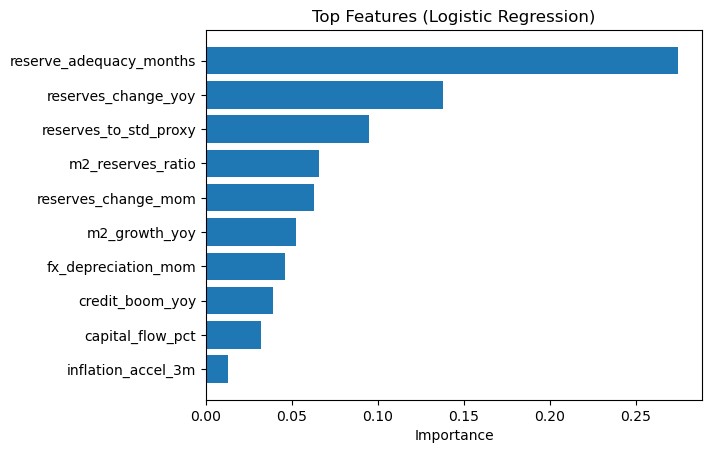

In [7]:
import matplotlib.pyplot as plt

top_features = coef_summary.head(10)

plt.figure()
plt.barh(top_features["feature"], top_features["abs_coef"])
plt.gca().invert_yaxis()

plt.title("Top Features (Logistic Regression)")
plt.xlabel("Importance")

plt.show()

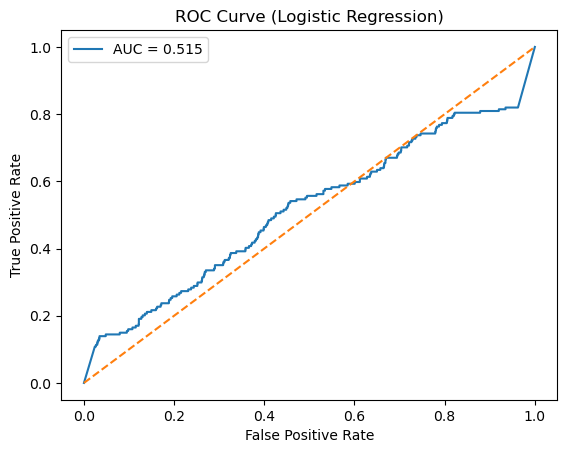

In [8]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, test_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic Regression)")
plt.legend()
plt.show()